In [1]:
import os

dataset_path = "/kaggle/input/datasets/alessiocorrado99/animals10/raw-img"

classes = sorted(os.listdir(dataset_path))
print(f"Number of classes: {len(classes)}")
print(f"Classes: {classes}")

Number of classes: 10
Classes: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']


In [2]:
label_map = {
    "cane": "dog",
    "cavallo": "horse",
    "elefante": "elephant",
    "farfalla": "butterfly",
    "gallina": "chicken",
    "gatto": "cat",
    "mucca": "cow",
    "pecora": "sheep",
    "ragno": "spider",
    "scoiattolo": "squirrel"
}
class_counts = {}
for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    count = len(os.listdir(cls_path))
    class_counts[label_map[cls]] = count

for animal, count in sorted(class_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"{animal:<12} {count} images")

print(f"\nTotal images: {sum(class_counts.values())}")

dog          4863 images
spider       4821 images
chicken      3098 images
horse        2623 images
butterfly    2112 images
cow          1866 images
squirrel     1862 images
sheep        1820 images
cat          1668 images
elephant     1446 images

Total images: 26179


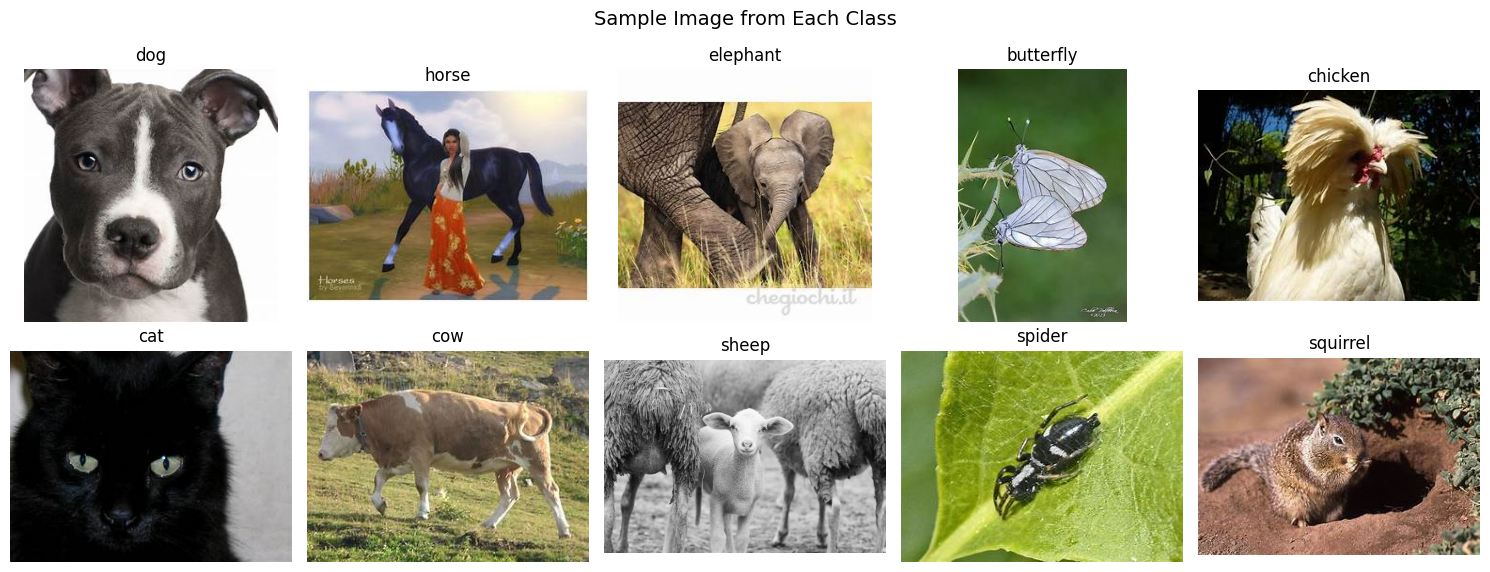

In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, (italian, english) in enumerate(label_map.items()):
    cls_path = os.path.join(dataset_path, italian)
    img_file = random.choice(os.listdir(cls_path))
    img = mpimg.imread(os.path.join(cls_path, img_file))
    axes[i].imshow(img)
    axes[i].set_title(english, fontsize=12)
    axes[i].axis("off")

plt.suptitle("Sample Image from Each Class", fontsize=14)
plt.tight_layout()
plt.show()

In [4]:
!pip install split-folders -q
import splitfolders

splitfolders. ratio(
    dataset_path,
    output="/kaggle/working/animals_split",
    seed=42,
    ratio=(0.7, 0.15, 0.15)
)

print("Split done!")

Copying files: 26179 files [01:49, 239.56 files/s]

Split done!


In [5]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

train_path = "/kaggle/working/animals_split/train"
val_path   = "/kaggle/working/animals_split/val"
test_path  = "/kaggle/working/animals_split/test"

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_augmented = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.2
)

val_test_preprocess = ImageDataGenerator(rescale=1./255)

train_loader = train_augmented.flow_from_directory(
    train_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_loader = val_test_preprocess.flow_from_directory(
    val_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_loader = val_test_preprocess.flow_from_directory(
    test_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 18322 images belonging to 10 classes.
Found 3922 images belonging to 10 classes.
Found 3935 images belonging to 10 classes.


In [7]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

print(f"Base model layers: {len(base_model.layers)}")
print(f"Trainable layers: {len([l for l in base_model.layers if l.trainable])}")

I0000 00:00:1789538280.874554      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789538280.877789      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Base model layers: 154
Trainable layers: 0


In [8]:
from tensorflow.keras import layers, models

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,593,610 (9.89 MB)

 Trainable params: 333,066 (1.27 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [9]:
# base_model (MobileNetV2)     →  extracts features (frozen, not trained)
# GlobalAveragePooling2D()     →  flattens feature maps into a 1D vector
# BatchNormalization()         →  stabilizes and speeds up training
# Dense(256, relu)             →  learns YOUR animal-specific patterns
# Dropout(0.4)                 →  randomly drops 40% neurons → prevents overfitting
# Dense(10, softmax)           →  outputs probability for each of 10 classes
#                                 [0.85, 0.02, 0.01, ...]  → sums to 1.0

In [10]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled and ready!")

Model compiled and ready!


In [11]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath="/kaggle/working/best_model.keras",
        monitor="val_accuracy",
        save_best_only=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6
    )
]

In [12]:
history = model.fit(
    train_loader,
    epochs=2,
    validation_data=val_loader,
    callbacks=callbacks
)

Epoch 1/2


2026-09-16 05:58:21.096413: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-16 05:58:21.251042: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-16 05:58:21.388047: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1789538303.858773     157 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


388/573 ━━━━━━━━━━━━━━━━━━━━ 1:01 331ms/step - accuracy: 0.8179 - loss: 0.6010

2026-09-16 06:00:41.092267: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-16 06:00:41.229359: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


573/573 ━━━━━━━━━━━━━━━━━━━━ 232s 372ms/step - accuracy: 0.8805 - loss: 0.3973 - val_accuracy: 0.9289 - val_loss: 0.2417 - learning_rate: 0.0010
Epoch 2/2
573/573 ━━━━━━━━━━━━━━━━━━━━ 194s 338ms/step - accuracy: 0.9176 - loss: 0.2653 - val_accuracy: 0.9416 - val_loss: 0.2175 - learning_rate: 0.0010


In [13]:
loss, accuracy = model.evaluate(test_loader)
print(f"Test accuracy: {accuracy * 100:.2f}%")
print(f"Test loss:     {loss:.4f}")

122/123 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9432 - loss: 0.1977

2026-09-16 06:05:25.869512: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-16 06:05:26.006930: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


123/123 ━━━━━━━━━━━━━━━━━━━━ 17s 140ms/step - accuracy: 0.9464 - loss: 0.2054
Test accuracy: 94.64%
Test loss:     0.2054


123/123 ━━━━━━━━━━━━━━━━━━━━ 15s 88ms/step


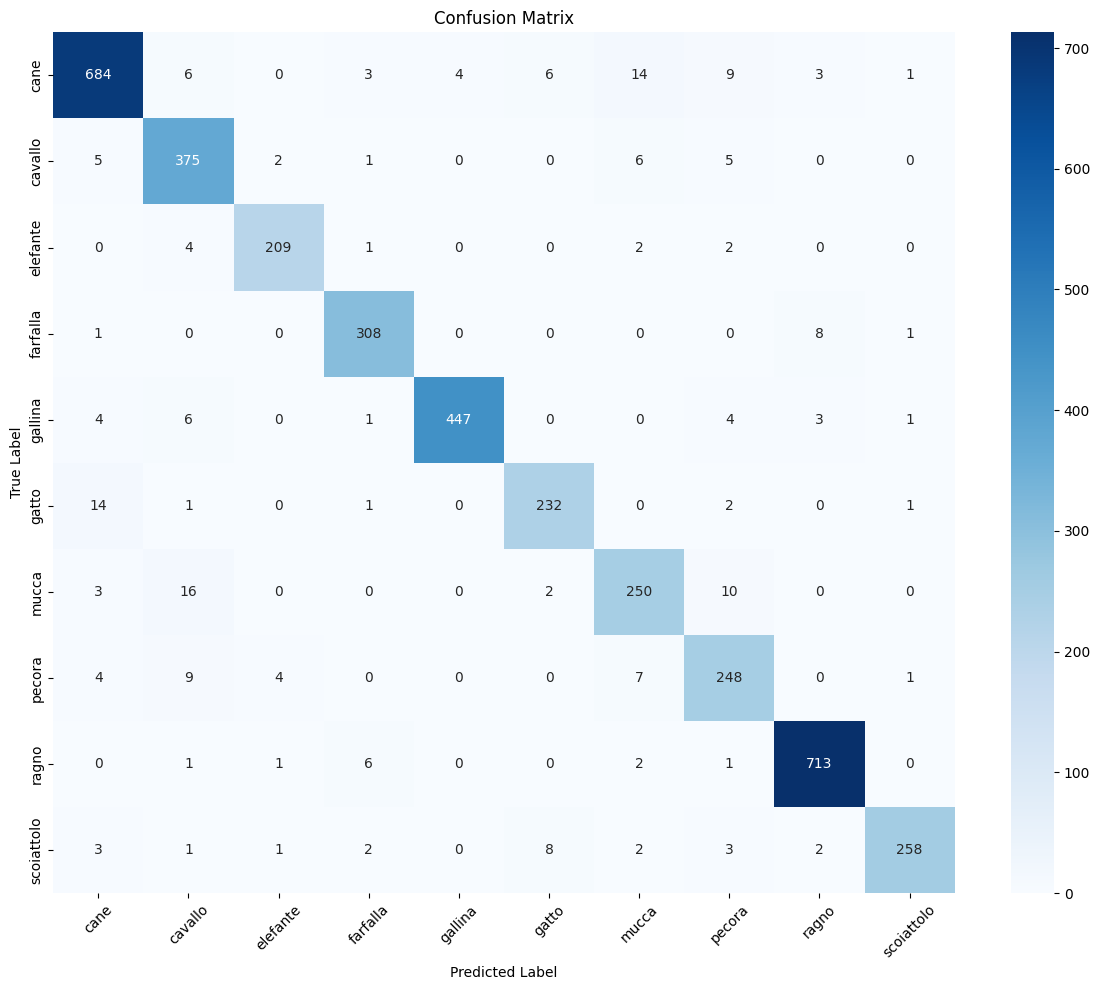


Classification Report:
              precision    recall  f1-score   support

        cane       0.95      0.94      0.94       730
     cavallo       0.89      0.95      0.92       394
    elefante       0.96      0.96      0.96       218
    farfalla       0.95      0.97      0.96       318
     gallina       0.99      0.96      0.97       466
       gatto       0.94      0.92      0.93       251
       mucca       0.88      0.89      0.89       281
      pecora       0.87      0.91      0.89       273
       ragno       0.98      0.98      0.98       724
  scoiattolo       0.98      0.92      0.95       280

    accuracy                           0.95      3935
   macro avg       0.94      0.94      0.94      3935
weighted avg       0.95      0.95      0.95      3935



In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(test_loader)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_loader.classes

class_names = list(test_loader.class_indices.keys())

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

In [15]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable = sum(1 for l in base_model.layers if l.trainable)
print(f"Trainable base layers: {trainable} / {len(base_model.layers)}")

Trainable base layers: 30 / 154


In [16]:
import tensorflow as tf

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model recompiled for fine-tuning!")

Model recompiled for fine-tuning!


In [17]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

fine_tune_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath="/kaggle/working/best_finetuned_model.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

history_fine = model.fit(
    train_loader,
    epochs=2,
    validation_data=val_loader,
    callbacks=fine_tune_callbacks
)

Epoch 1/2
573/573 ━━━━━━━━━━━━━━━━━━━━ 225s 365ms/step - accuracy: 0.9061 - loss: 0.2972 - val_accuracy: 0.9457 - val_loss: 0.2051
Epoch 2/2
573/573 ━━━━━━━━━━━━━━━━━━━━ 196s 343ms/step - accuracy: 0.9169 - loss: 0.2511 - val_accuracy: 0.9488 - val_loss: 0.1856


In [18]:
loss, accuracy = model.evaluate(test_loader)
print(f"Test accuracy after fine-tuning: {accuracy * 100:.2f}%")
print(f"Test loss after fine-tuning:     {loss:.4f}")

123/123 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - accuracy: 0.9522 - loss: 0.1887
Test accuracy after fine-tuning: 95.22%
Test loss after fine-tuning:     0.1887


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.preprocessing import image

label_map_reverse = {
    "cane": "dog",        "cavallo": "horse",
    "elefante": "elephant","farfalla": "butterfly",
    "gallina": "chicken",  "gatto": "cat",
    "mucca": "cow",        "pecora": "sheep",
    "ragno": "spider",     "scoiattolo": "squirrel"
}

class_indices = test_loader.class_indices
index_to_label = {v: label_map_reverse[k] for k, v in class_indices.items()}

def predict_animal(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    predictions = model.predict(img_array)
    predicted_index = np.argmax(predictions[0])
    predicted_label = index_to_label[predicted_index]
    confidence = predictions[0][predicted_index] * 100

    plt.imshow(mpimg.imread(img_path))
    plt.axis("off")
    plt.title(f"Predicted: {predicted_label} ({confidence:.2f}%)")
    plt.show()

    print(f"Predicted animal: {predicted_label}")
    print(f"Confidence:       {confidence:.2f}%")
    print("\nAll class probabilities:")
    for idx, prob in enumerate(predictions[0]):
        print(f"  {index_to_label[idx]:<12} {prob*100:.2f}%")

2026-09-16 06:20:23.900420: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-16 06:20:24.038408: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step


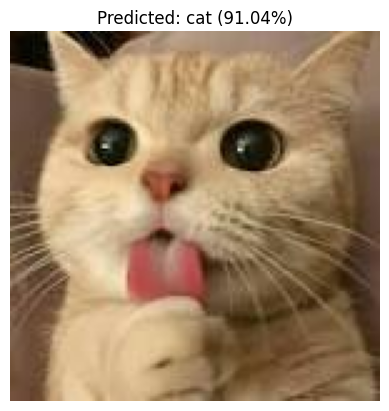

Predicted animal: cat
Confidence:       91.04%

All class probabilities:
  dog          8.74%
  horse        0.00%
  elephant     0.00%
  butterfly    0.21%
  chicken      0.00%
  cat          91.04%
  cow          0.00%
  sheep        0.00%
  spider       0.01%
  squirrel     0.00%


In [22]:
sample_path = "/kaggle/input/datasets/nagagopalchimata/catimage/download.jfif"
predict_animal(sample_path)